<a href="https://colab.research.google.com/github/hatamimatt/ClimateDataScience/blob/main/nex_gddp_cmip6_extremePrecipitationWorkflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install intake intake-esm gcsfs xarray dask netCDF4 cftime s3fs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.9 MB/s eta 0:00:00


In [44]:
import intake
import xarray as xr
import numpy as np
import pandas as pd
import gcsfs
import s3fs
import matplotlib.pyplot as plt

In [18]:
fs = s3fs.S3FileSystem(anon=True)

# Test the public AWS bucket

fs.ls("nex-gddp-cmip6")[:10]

['nex-gddp-cmip6/NEX-GDDP-CMIP6',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6-Tech_Note.pdf',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6-v2-Tech_Note.pdf',
 'nex-gddp-cmip6/index.html',
 'nex-gddp-cmip6/index_md5.txt',
 'nex-gddp-cmip6/index_md5.txt.md5',
 'nex-gddp-cmip6/index_v1.1_md5.txt',
 'nex-gddp-cmip6/index_v1.1_md5.txt.md5',
 'nex-gddp-cmip6/index_v1.2_md5.txt',
 'nex-gddp-cmip6/index_v1.2_md5.txt.md5']

In [20]:
fs.ls("nex-gddp-cmip6/NEX-GDDP-CMIP6")[:5]

['nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-ESM1-5',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/BCC-CSM2-MR',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/CESM2',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/CESM2-WACCM']

In [21]:
fs.ls("nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2")[:5]

['nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp126',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp370',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp585']

In [23]:
fs.ls("nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245")[:10]

['nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1']

In [24]:
fs.ls("nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1")[:10]

['nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/hurs',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/huss',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/rlds',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/rsds',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/sfcWind',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/tas',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/tasmax',
 'nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/tasmin']

In [25]:
model = "ACCESS-CM2"
scenario = "ssp245"
variant = "r1i1p1f1"
variable = "pr"

baseline_years = range(1981, 2011)
future_years = range(2071, 2101)

# Florida bounding box
lat_min, lat_max = 24, 31
lon_min, lon_max = -88, -79

In [26]:
def get_files(model, scenario, variant, variable, years):
    folder = f"nex-gddp-cmip6/NEX-GDDP-CMIP6/{model}/{scenario}/{variant}/{variable}"

    all_files = fs.glob(folder + "/*.nc")

    selected_files = []

    for file in all_files:
        for year in years:
            if str(year) in file:
                selected_files.append("s3://" + file)

    return sorted(selected_files)

In [27]:
hist_files = get_files(
    model=model,
    scenario="historical",
    variant=variant,
    variable=variable,
    years=baseline_years
)

future_files = get_files(
    model=model,
    scenario=scenario,
    variant=variant,
    variable=variable,
    years=future_years
)

print("Historical files:", len(hist_files))
print("Future files:", len(future_files))

print(hist_files[:2])
print(future_files[:2])

Historical files: 90
Future files: 90
['s3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/pr/pr_day_ACCESS-CM2_historical_r1i1p1f1_gn_1981.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/pr/pr_day_ACCESS-CM2_historical_r1i1p1f1_gn_1981_v1.1.nc']
['s3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr/pr_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2071.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr/pr_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2071_v1.1.nc']


In [30]:
def get_latest_files_by_year(model, scenario, variant, variable, years):
    folder = f"nex-gddp-cmip6/NEX-GDDP-CMIP6/{model}/{scenario}/{variant}/{variable}"

    all_files = fs.glob(folder + "/*.nc")

    selected_files = []

    for year in years:
        year_files = [f for f in all_files if f"_{year}" in f]

        if len(year_files) == 0:
            print(f"No file found for {year}")
            continue

        # Prefer v1.2, then v1.1, then original
        v12_files = [f for f in year_files if "_v1.2.nc" in f]
        v11_files = [f for f in year_files if "_v1.1.nc" in f]

        if len(v12_files) > 0:
            chosen_file = v12_files[0]
        elif len(v11_files) > 0:
            chosen_file = v11_files[0]
        else:
            chosen_file = year_files[0]

        selected_files.append("s3://" + chosen_file)

    return selected_files

In [31]:
hist_files = get_latest_files_by_year(
    model=model,
    scenario="historical",
    variant=variant,
    variable=variable,
    years=baseline_years
)

future_files = get_latest_files_by_year(
    model=model,
    scenario=scenario,
    variant=variant,
    variable=variable,
    years=future_years
)

print("Historical files:", len(hist_files))
print("Future files:", len(future_files))

print(hist_files[:3])
print(future_files[:3])

Historical files: 30
Future files: 30
['s3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/pr/pr_day_ACCESS-CM2_historical_r1i1p1f1_gn_1981_v1.1.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/pr/pr_day_ACCESS-CM2_historical_r1i1p1f1_gn_1982_v1.1.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/pr/pr_day_ACCESS-CM2_historical_r1i1p1f1_gn_1983_v1.1.nc']
['s3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr/pr_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2071_v1.1.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr/pr_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2072_v1.1.nc', 's3://nex-gddp-cmip6/NEX-GDDP-CMIP6/ACCESS-CM2/ssp245/r1i1p1f1/pr/pr_day_ACCESS-CM2_ssp245_r1i1p1f1_gn_2073_v1.1.nc']


In [32]:
def open_florida_precip(files):
    open_files = fs.open_files(files)

    ds = xr.open_mfdataset(
        open_files,
        engine="h5netcdf",
        combine="by_coords",
        chunks={"time": 90}
    )

    pr = ds["pr"] * 86400  # kg m-2 s-1 to mm/day

    if pr.lon.max() > 180:
        pr_fl = pr.sel(
            lat=slice(24, 31),
            lon=slice(360 - 88, 360 - 79)
        )
    else:
        pr_fl = pr.sel(
            lat=slice(24, 31),
            lon=slice(-88, -79)
        )

    return pr_fl

In [35]:
def open_florida_precip(files):

    ds = xr.open_mfdataset(
        files,
        engine="h5netcdf",
        combine="by_coords",
        chunks={"time": 90},
        backend_kwargs={"storage_options": {"anon": True}}
    )

    pr = ds["pr"] * 86400  # convert to mm/day

    # Handle longitude
    if pr.lon.max() > 180:
        pr_fl = pr.sel(
            lat=slice(24, 31),
            lon=slice(360 - 88, 360 - 79)
        )
    else:
        pr_fl = pr.sel(
            lat=slice(24, 31),
            lon=slice(-88, -79)
        )

    return pr_fl

In [36]:
hist_pr = open_florida_precip(hist_files)
future_pr = open_florida_precip(future_files)

hist_pr

<xarray.DataArray 'pr' (time: 10957, lat: 28, lon: 36)> Size: 44MB
dask.array<getitem, shape=(10957, 28, 36), dtype=float32, chunksize=(90, 28, 36), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 88kB 1981-01-01T12:00:00 ... 2010-12-31T12...
  * lat      (lat) float64 224B 24.12 24.38 24.62 24.88 ... 30.38 30.62 30.88
  * lon      (lon) float64 288B 272.1 272.4 272.6 272.9 ... 280.4 280.6 280.9
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [37]:
hist_wet = hist_pr.where(hist_pr >= 1)
threshold_95 = hist_wet.quantile(0.95, dim="time").compute()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [39]:
def count_extreme_days_per_year(pr_data, threshold):

    extreme = pr_data > threshold

    yearly_count = extreme.resample(time="YS").sum()

    weights = np.cos(np.deg2rad(yearly_count.lat))

    yearly_mean = yearly_count.weighted(weights).mean(dim=("lat", "lon"))

    return yearly_mean.compute()

In [40]:
hist_extreme = count_extreme_days_per_year(hist_pr, threshold_95)
future_extreme = count_extreme_days_per_year(future_pr, threshold_95)

In [41]:
hist_df = pd.DataFrame({
    "year": hist_extreme["time.year"].values,
    "extreme_days": hist_extreme.values,
    "period": "1981-2010"
})

future_df = pd.DataFrame({
    "year": future_extreme["time.year"].values,
    "extreme_days": future_extreme.values,
    "period": "2071-2100"
})

df = pd.concat([hist_df, future_df], ignore_index=True)

df.head()

,year,extreme_days,period
0,1981,1.840412,1981-2010
1,1982,2.545134,1981-2010
2,1983,1.878800,1981-2010
3,1984,3.946721,1981-2010
4,1985,2.285736,1981-2010


In [42]:
summary = df.groupby("period")["extreme_days"].mean()

baseline_mean = summary["1981-2010"]
future_mean = summary["2071-2100"]

change_days = future_mean - baseline_mean
change_percent = (change_days / baseline_mean) * 100

print("Historical extreme rainfall days/year:", round(baseline_mean, 2))
print("Future extreme rainfall days/year:", round(future_mean, 2))
print("Change in days/year:", round(change_days, 2))
print("Percent change:", round(change_percent, 2), "%")

Historical extreme rainfall days/year: 2.51
Future extreme rainfall days/year: 3.14
Change in days/year: 0.63
Percent change: 25.12 %


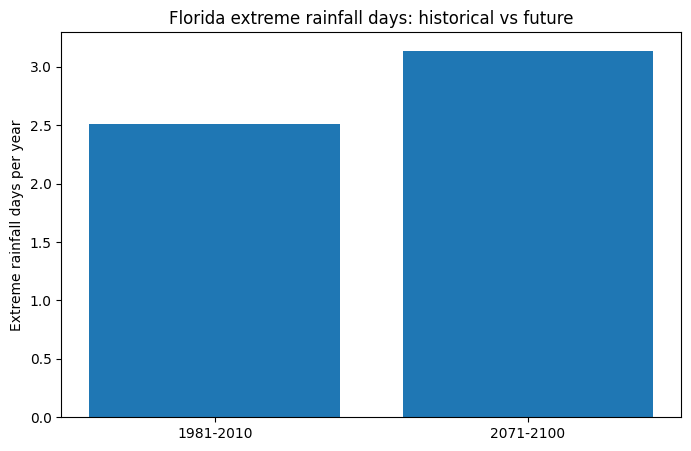

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(summary.index, summary.values)
plt.ylabel("Extreme rainfall days per year")
plt.title("Florida extreme rainfall days: historical vs future")
plt.show()